## Russian River Estuary – Merge Data

This notebook assembles the dataset used for seepage analysis by merging:
1. **USGS river discharge** from Hacienda Bridge (11467000) and Austin Creek (11467200)
2. **Estuary water level** from the Sonoma County Water Agency visitor center gauge and the USGS Jenner gauge (11467270)
3. **Inlet state** (open/closed) from webcam-based closure records
4. **Ocean water level** from the NOAA Point Reyes tide gauge (9415020)
5. **Hypsometric data** for stage–volume conversion

The merged 15-minute time series is saved as `merged.pkl` for downstream analysis.

In [1]:
# Datum conversion notes:
#   NAVD88 and NGVD29 differ by approximately 2.73 feet at this location
#   (NGVD29 is ~2.73 ft higher than NAVD88).
#   Visitor center gauge data are in NGVD29 feet; we convert to NAVD88 meters.
#   USGS gauge height is in NAVD88 feet; multiply by 0.3048 to get meters.
#   Reference: https://pubs.usgs.gov/sir/2010/5040/section.html

### Imports and configuration

In [2]:


import pandas as pd

# std libs
from pathlib import Path
import sys, importlib

# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use("ggplot")
mpl.rcParams.update({"figure.dpi": 300, "figure.figsize": (12, 6)})



In [3]:
# paths: root = this file/notebook folder
try:
    here = Path(__file__).resolve().parent   # .py files
except NameError:
    here = Path.cwd().resolve()              # notebooks

root    = here.parent                                
scripts = root / "src"
if str(scripts) not in sys.path:
    sys.path.insert(0, str(scripts))          # ensure your modules are found first

# dev-friendly reload while keeping import *
def _reload_star(mod_names):
    importlib.invalidate_caches()
    for name in mod_names:
        if name in sys.modules:
            del sys.modules[name]

_mods = ["plot_config", "timeseries_functions", "seepage_analysis", "seepage_plots"]
_reload_star(_mods)

from plot_config import *
from timeseries_functions import *
from seepage_analysis import *
from seepage_plots import *

data_path = root / "data"

import hydrofunctions as hf
hf.__version__


'0.2.4'

In [4]:
%matplotlib inline

### Read hypsometric data

In [5]:
hypso = pd.read_excel(data_path / "RR_stage_storage.xlsx", header=3)

hypso.columns = ['h_m', 'vol_m3', 'A_m2']
hypso['h_m'] = hypso['h_m'] + 2.73*0.3048

hypso.head()
hypso['vol_m3'].max()/ hypso['h_m'].max()
# 2235803.62 m2, 2.2 km2

2235803.627782409

### Get USGS gauge data

In [6]:
# Fetch 15-min discharge from Hacienda Bridge (USGS 11467000)
# parameterCd 00060 = discharge in cfs
site_Hacienda = hf.NWIS(
    '11467000', 'iv', start_date='2000-04-26', parameterCd='00060'    
)

Hacienda = site_Hacienda.df('data').rename(
    columns={'USGS:11467000:00060:00000': 'Q_Hacienda'}, inplace=False
)

Hacienda.index = Hacienda.index.round('15min')
Hacienda.to_parquet(data_path / "interim" / "Hacienda.parquet")

Requested data from https://nwis.waterservices.usgs.gov/nwis/iv/?format=json%2C1.1&sites=11467000&parameterCd=00060&startDT=2000-04-26


In [7]:
# Fetch 15-min discharge from Austin Creek (USGS 11467200)
# Only perennial tributary to the lower Russian River
site_Austin = hf.NWIS(
    '11467200', 'iv', start_date='2000-04-26', parameterCd='00060'   
)

Austin = site_Austin.df('data').rename(
    columns={'USGS:11467200:00060:00000': 'Q_Austin'},
    inplace=False
)

Austin.index = Austin.index.round('15min')
Austin.to_parquet(data_path / "interim" / "Austin.parquet")

Requested data from https://nwis.waterservices.usgs.gov/nwis/iv/?format=json%2C1.1&sites=11467200&parameterCd=00060&startDT=2000-04-26


In [8]:
# Combine Hacienda + Austin Creek into total river discharge Q
# Austin Creek contributes ~8% of total discharge on average
overlap = list(set(Hacienda.index) & set( Austin.index))

Hacienda.loc[overlap, 'Q_Austin'] = Austin.loc[overlap].Q_Austin
Hacienda.loc[Hacienda['Q_Austin'].isna(), 'Q_Austin'] = 0

Hacienda['Q'] = Hacienda['Q_Austin'] +  Hacienda['Q_Hacienda']

In [9]:
Hacienda['Q_Austin'].mean()/Hacienda['Q_Hacienda'].mean()

0.08023480877066644

In [10]:
len(Hacienda.query("Q > 0")),len(Hacienda.query("Q_Hacienda > 0"))

(910583, 910583)

In [11]:
# Fetch 15-min stage from USGS Jenner gauge (11467270)
# parameterCd 00065 = gauge height in feet NAVD88
# This gauge was installed in 2018
site_Jenner = hf.NWIS(
    '11467270', 'iv', start_date='2018-01-01', parameterCd='00065'    
)

Jenner = site_Jenner.df('stage').rename(columns={'USGS:11467270:00065-229225:00000':'USGS_h'
                                                }, inplace=False)[['USGS_h']]

Jenner.to_parquet(data_path / "interim" / "Jenner.parquet")

Requested data from https://nwis.waterservices.usgs.gov/nwis/iv/?format=json%2C1.1&sites=11467270&parameterCd=00065&startDT=2018-01-01


### Read visitor center gauge data

The Sonoma County Water Agency operates a water-level gauge at the visitor center, 1.5 km upstream of the inlet. These CSV files contain hourly stage data in NGVD29 feet (2011–2023).

In [12]:
vc_dir = root / "data" / "visitor_center"

Jenner2011 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2011.csv")
Jenner2012 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2012.csv")
Jenner2013 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2013.csv")
Jenner2014 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2014.csv")
Jenner2015 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2015.csv")
Jenner2016 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2016.csv")
Jenner2017 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2017.csv")
Jenner2018 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2018.csv")
Jenner2019 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2019.csv")
Jenner2020 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2020.csv")
Jenner2021 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2021.csv")
Jenner2022 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2022.csv")
Jenner2023 = pd.read_csv(vc_dir / "Jenner_River_Gauge_2023.csv")

In [13]:
# Combine visitor center files
Jgauge = pd.concat([Jenner2011, Jenner2012, Jenner2013, Jenner2014, Jenner2015, Jenner2016, Jenner2017,
                    Jenner2018, Jenner2019, Jenner2020, Jenner2021, Jenner2022, Jenner2023])
Jgauge = Jgauge.rename(
    {'Time (Local)' : 'Time', 'Channel 1 (Feet)' : 'Channel_1', ' Channel 2 ()': 'Channel_2'}, axis = 1)
Jgauge['Time'] = pd.to_datetime(Jgauge['Time'])
# Jgauge['date'] = Jgauge.Time.dt.date

Jgauge = Jgauge.set_index(Jgauge.Time)[['Channel_1']].tz_localize('US/Pacific', ambiguous = True).tz_convert("UTC")
Jgauge.head()


,Channel_1
Time,
2011-08-23 16:30:00+00:00,-8.37
2011-08-23 16:45:00+00:00,-8.41
2011-08-30 17:30:00+00:00,-8.41
2011-08-30 17:45:00+00:00,-8.41
2011-08-30 18:00:00+00:00,1.35


#### Combine and merge visitor center with USGS data

Concatenate the annual visitor center CSVs, convert timestamps to UTC, then join with the USGS Jenner gauge and Hacienda discharge into a single `hourly` DataFrame. All elevations are converted to meters NAVD88 and discharge to m³/s.

In [14]:
# Join USGS Jenner gauge with Hacienda+Austin discharge
hourly = Jenner.join(Hacienda[[ 'Q']], how='outer')

# Convert USGS gauge height from feet to meters (NAVD88)
hourly['USGS_h'] = hourly['USGS_h']*0.3048
# Convert discharge from cubic feet per second to m³/s
hourly['Q'] = hourly['Q']*0.0283168

# Join visitor center gauge data
hourly = hourly.join(Jgauge, how='outer')
hourly = hourly.rename({"Channel_1" : 'visitor_h'}, axis = 1)
# Remove spurious readings below -3 ft
hourly.loc[hourly['visitor_h'] < -3, 'visitor_h'] = np.nan

# Convert visitor center gauge from NGVD29 feet to NAVD88 meters
hourly['visitor_h']  = hourly['visitor_h']*0.3048 + 2.73*0.3048

# Trim to the period with valid visitor center data
start_vc = hourly.query("visitor_h > 0").index[0]
end_vc = hourly.query("visitor_h > 0").index[-1]
hourly = hourly.loc[start_vc:end_vc]
hourly = hourly.groupby(hourly.index).mean()

### Read inlet state data

Inlet open/closed state from two sources:
- **Speiser**: webcam-based record compiled by W. Speiser
- **ESA**: closure record maintained by ESA consultants (through 2022)

States are merged, with manual corrections for known mislabeled dates.

In [15]:
# Read Speiser webcam-based closure record
Inlet = pd.read_csv(data_path / 'closures/Russian_InletState_Speiser.csv')
Inlet = Inlet.sort_values("Date")
Inlet = Inlet.set_index(pd.to_datetime(Inlet.Date))
Inlet.loc[Inlet.query("State == '-'").index, 'State'] = np.nan
Inlet.loc[Inlet.query("State == '0'").index, 'State'] = 0
Inlet.loc[Inlet.query("State == '1'").index, 'State'] = 1

# Read ESA closure record (through 2022)
Inlet_ESA = pd.read_excel(data_path / 'closures/ESA RR closure record - through 2022.xlsx', header = 2)
Inlet_ESA.columns = ['Date', 'drop', 'State']

Inlet_ESA = Inlet_ESA.set_index(pd.to_datetime(Inlet_ESA.Date))
Inlet_ESA = Inlet_ESA.sort_index()
Inlet_ESA = Inlet_ESA[['State']]

# Join both records for cross-reference
Inlet_ESA = Inlet_ESA.join(Inlet[['State']].rename({"State" : 'State_WS'}, axis = 1), how='outer')
Inlet_ESA.index = Inlet_ESA.index.tz_localize("UTC")

#### Correct mislabeled closures

In [16]:
# Manually correct mislabeled closure dates identified from gauge/webcam review

# Oct 22 – Nov 26, 2021: should be open (State = 0)
start = pd.to_datetime('2021-10-22').tz_localize("UTC")
end = pd.to_datetime('2021-11-26').tz_localize("UTC")
Inlet_ESA.loc[start:end, 'State'] = 0

# Jan 25–30, 2015: should be open
start = pd.to_datetime('2015-01-25').tz_localize("UTC")
end = pd.to_datetime('2015-01-30').tz_localize("UTC")
Inlet_ESA.loc[start:end, 'State'] = 0

# Oct 4, 2015: should be open
start = pd.to_datetime('2015-10-4').tz_localize("UTC")
end = pd.to_datetime('2015-10-4').tz_localize("UTC")
Inlet_ESA.loc[start:end, 'State'] = 0

#### Copy 2023 from Speiser to ESA

In [17]:
# Copy 2023 from Speiser to ESA
copy_start = np.where(~Inlet_ESA['State'].isna() )[0][-1] + 1
copy_end = np.where(~Inlet_ESA['State_WS'].isna() )[0][-1] + 1

rows_to_update = Inlet_ESA.iloc[copy_start:copy_end].index
Inlet_ESA.loc[rows_to_update,'State'] = Inlet_ESA.loc[rows_to_update, 'State_WS']

### Fetch NOAA tide gauge data

Ocean water levels from the Point Reyes (9415020) and Point Arena (9416841) NOAA tide gauges, in meters NAVD88. Set `fetch_data = 0` to load from cached pickle files instead of re-downloading.

In [18]:
import noaa_coops
# Fetch or load Point Reyes tide gauge data (NOAA station 9415020)
fetch_data = 1
if fetch_data == 1:
    from noaa_coops import Station
    pt_reyes = Station(id="9415020")
    df_water_levels = pt_reyes.get_data(
        begin_date="20110101",
        end_date="20231026",
        product="water_level",
        datum="NAVD",
        units="metric",
        time_zone="gmt")

    df_water_levels.to_pickle(data_path / 'noaa_coops_9415020.pkl')
else:
    df_water_levels = pd.read_pickle(data_path /  'noaa_coops_9415020.pkl')

# Round to 15-min intervals and localize to UTC
df_water_levels.index = df_water_levels.index.round('15min').tz_localize('GMT').tz_convert('UTC')

In [19]:
# Fetch or load Point Arena tide gauge data (NOAA station 9416841)
if fetch_data == 1:
    from noaa_coops import Station
    pt_arena = Station(id="9416841")
    df_pt_arena = pt_arena.get_data(
        begin_date="20110101",
        end_date="20231026",
        product="water_level",
        datum="NAVD",
        units="metric",
        time_zone="gmt")

    df_pt_arena.to_pickle(data_path / 'noaa_coops_9416841.pkl')
else:
    df_pt_arena = pd.read_pickle(data_path / 'noaa_coops_9416841.pkl')

# Round to 15-min intervals and localize to UTC
df_pt_arena.index = df_pt_arena.index.round('15min').tz_localize('GMT').tz_convert('UTC')

### Merge hourly and ocean data

In [20]:
# Merge inlet state, estuary gauge, discharge, and ocean water level
Inlet_ESA['date'] = Inlet_ESA.index.date
hourly['date'] = hourly.index.date

merged = hourly[hourly.date <= Inlet_ESA.date.max()].merge(Inlet_ESA)
merged.index = hourly[hourly.date <= Inlet_ESA.date.max()].index

# Trim to period with valid visitor center data
start = merged.query("visitor_h > 0").index[0]
end = merged.query("visitor_h > 0").index[-1]

# Join ocean water level ('v' column from Point Reyes)
merged = merged.join(df_water_levels[['v']], how = 'outer').loc[start:end]
merged = merged.groupby(merged.index).first()

#### Gap-fill and compute derived fields

Linearly interpolate short gaps (≤ 24 timesteps = 6 hours) in both the USGS and visitor center gauge records. Longer gaps are left as NaN. Also compute the difference between the two gauges and the closure event lengths.

In [21]:
# Identify gap lengths and interpolate short gaps in USGS gauge
result = sequence_lengths(merged.USGS_h.isna())
merged['USGS_gap'] = result
merged['USGS_filled'] = merged['USGS_h'].interpolate(method='polynomial', order=1)
merged.loc[merged.query('USGS_gap > 24').index, 'USGS_filled'] = np.nan  # leave long gaps as NaN

# Same for visitor center gauge
result = sequence_lengths(merged.visitor_h.isna())
merged['visitor_gap'] = result
merged['visitor_filled'] = merged['visitor_h'].interpolate(method='polynomial', order=1)
merged.loc[merged.query('visitor_gap > 24').index, 'visitor_filled'] = np.nan

# Gauge-to-gauge difference (USGS minus visitor center)
merged['USGS-visitor'] = merged['USGS_h'] - merged['visitor_h']

In [22]:
# Compute consecutive closure lengths (number of timesteps the inlet stays in each state)
result = sequence_lengths(merged.State)
merged['closure'] = result


### Filter out days with tidal signature in estuary water level

The following applies a short-time Fourier transform (STFT) to the estuary water-level time series to extract the magnitude of the spectral component associated with 12 and 24 hour periods
    

In [23]:
# Compute STFT spectral power at 24-hr and 12-hr periods for both gauges
# High power at 12 hr indicates tidal forcing (inlet open)
merged = add_power_visitor(merged, 24, label = 'visitor_24_hr' )
merged = add_power_USGS(merged, 24, label = 'USGS_24_hr' )

merged = add_power_visitor(merged, 12, label = 'visitor_12_hr' )
merged = add_power_USGS(merged, 12, label = 'USGS_12_hr' )

In [24]:
# Save final merged dataset for use in analysis notebooks
merged.to_pickle("merged.pkl")

In [25]:
# Median daily tidal range at Point Reyes (min and max ocean water level)
merged.groupby('date')['v'].min().median(), \
merged.groupby('date')['v'].max().median()

(0.046, 1.794)

### Quality checks

Visual inspection of the merged time series: gap-filled vs. raw gauge data, estuary–ocean water level comparisons during open and closed inlet conditions, and identification of out-of-bounds readings (above the hypsometric maximum of 3.63 m NAVD88).

<Axes: >

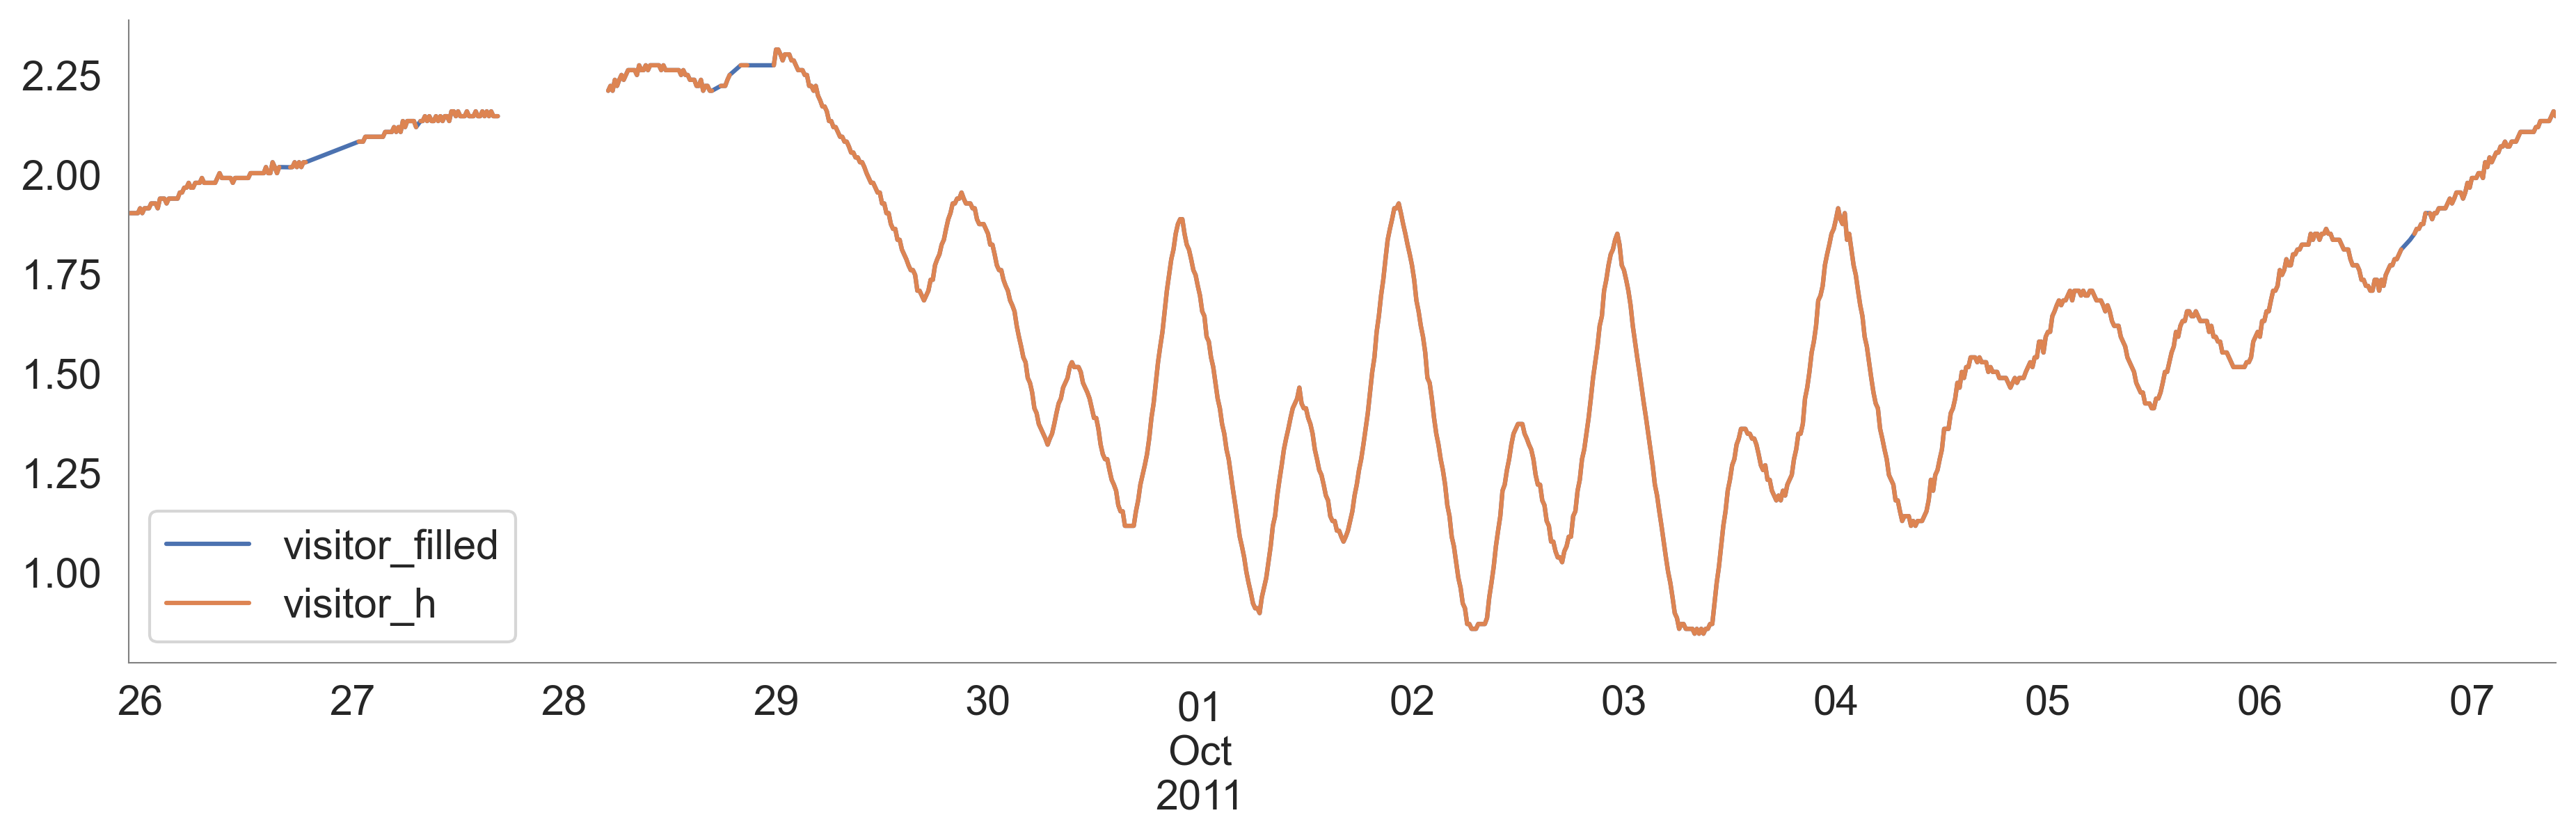

In [26]:
fig, ax = plt.subplots(1, figsize = (15, 4))
start_ind = np.where((merged['visitor_gap'] > 1) & (merged['visitor_gap'] < 40) )[0][100]

merged[[ 'visitor_filled','visitor_h',]][start_ind - 100:start_ind + 1000].plot(ax = ax)

In [27]:
merged[[ 'visitor_filled','visitor_h',]].isna().sum()

visitor_filled    37096
visitor_h         42601
dtype: int64

In [28]:
rename_dict = {'v': '$h_{ocn}$  (Point Reyes)', 'visitor_filled': '$h$ (Visitor center gauge)',
               'State' : 'Mouth state (closed = 1)'}

<Axes: >

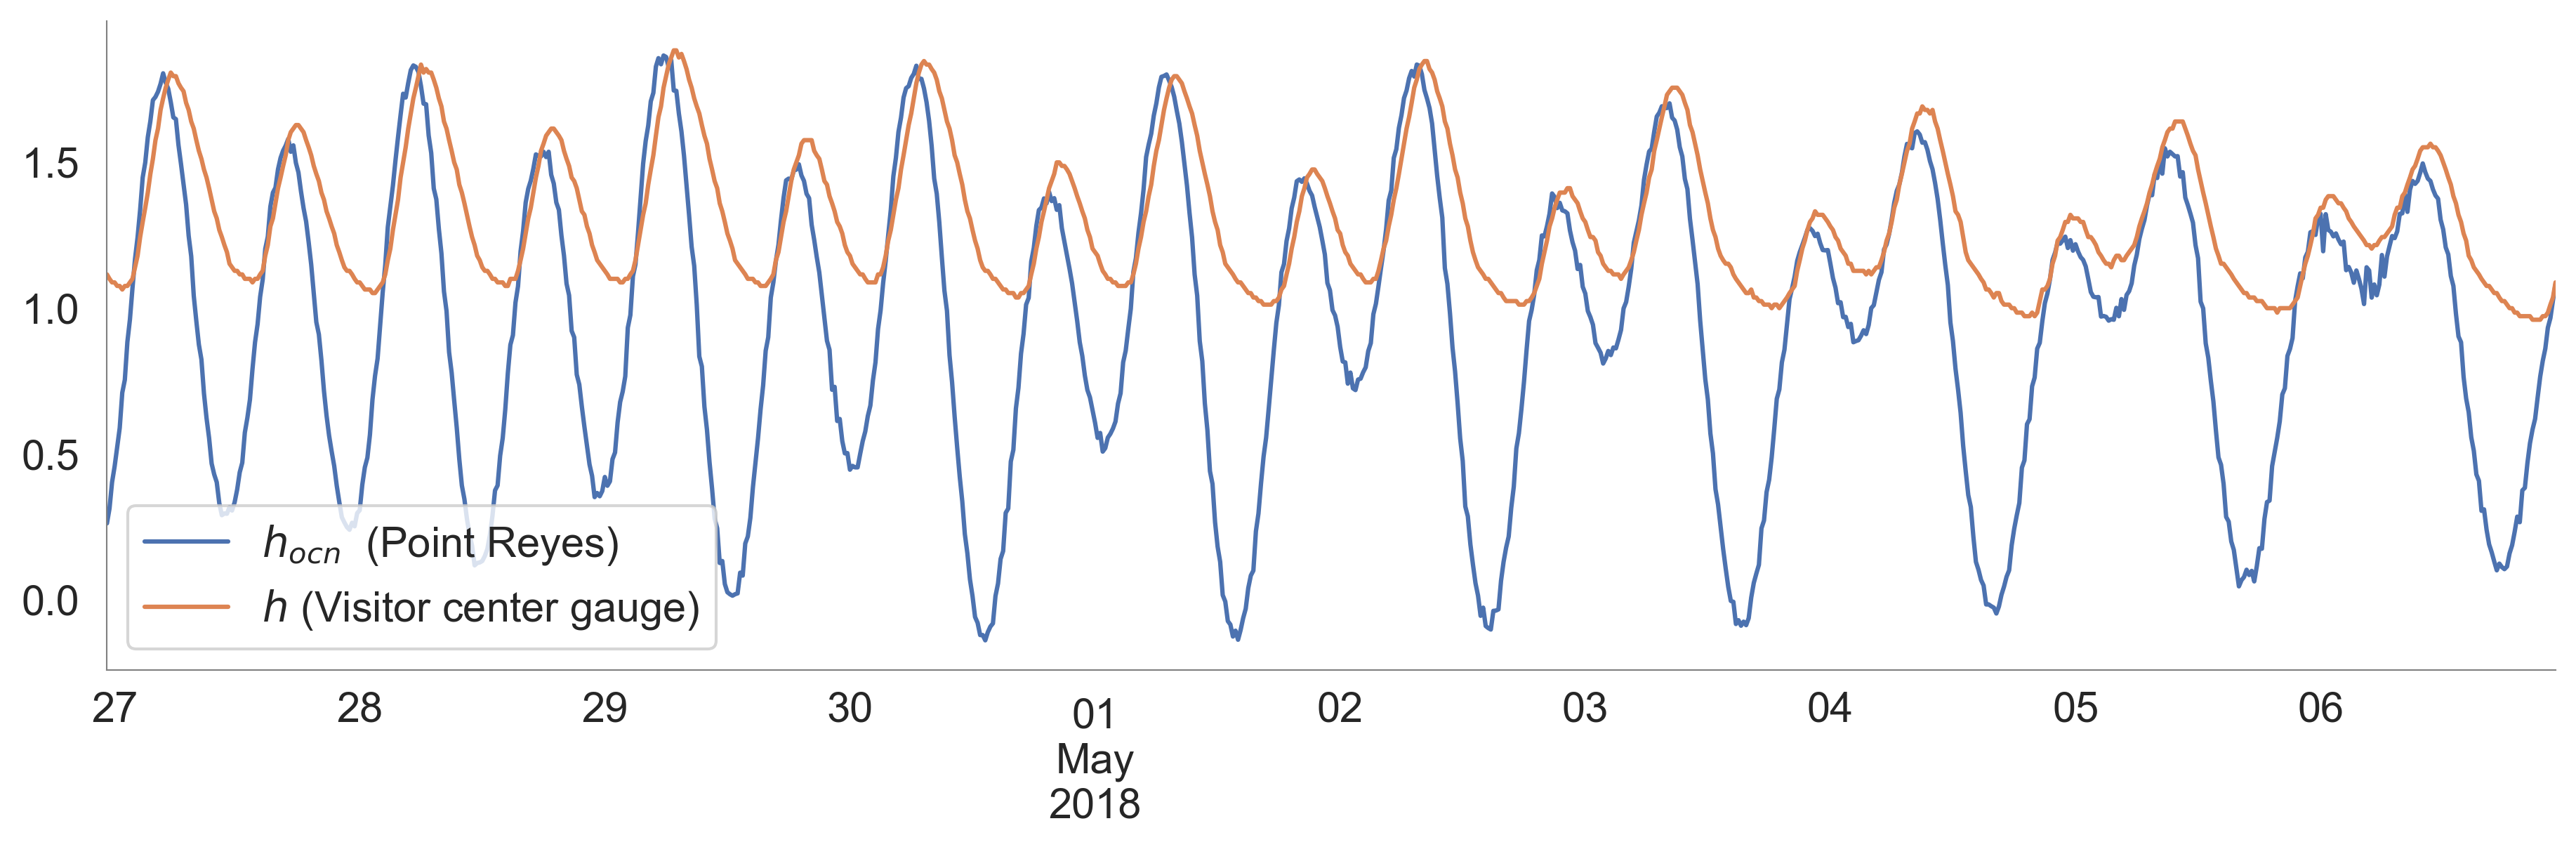

In [29]:
start_ind = np.where(merged.USGS_h >0)[0][0]
days = 10
plt.figure(figsize = (15, 4))

merged[['v', 'visitor_filled']].rename(rename_dict, axis= 1
        ).iloc[start_ind:start_ind+days*24*4].plot(ax = plt.gca())
# maximum difference at ocean low tide


Text(0, 0.5, 'm (NAVD)')

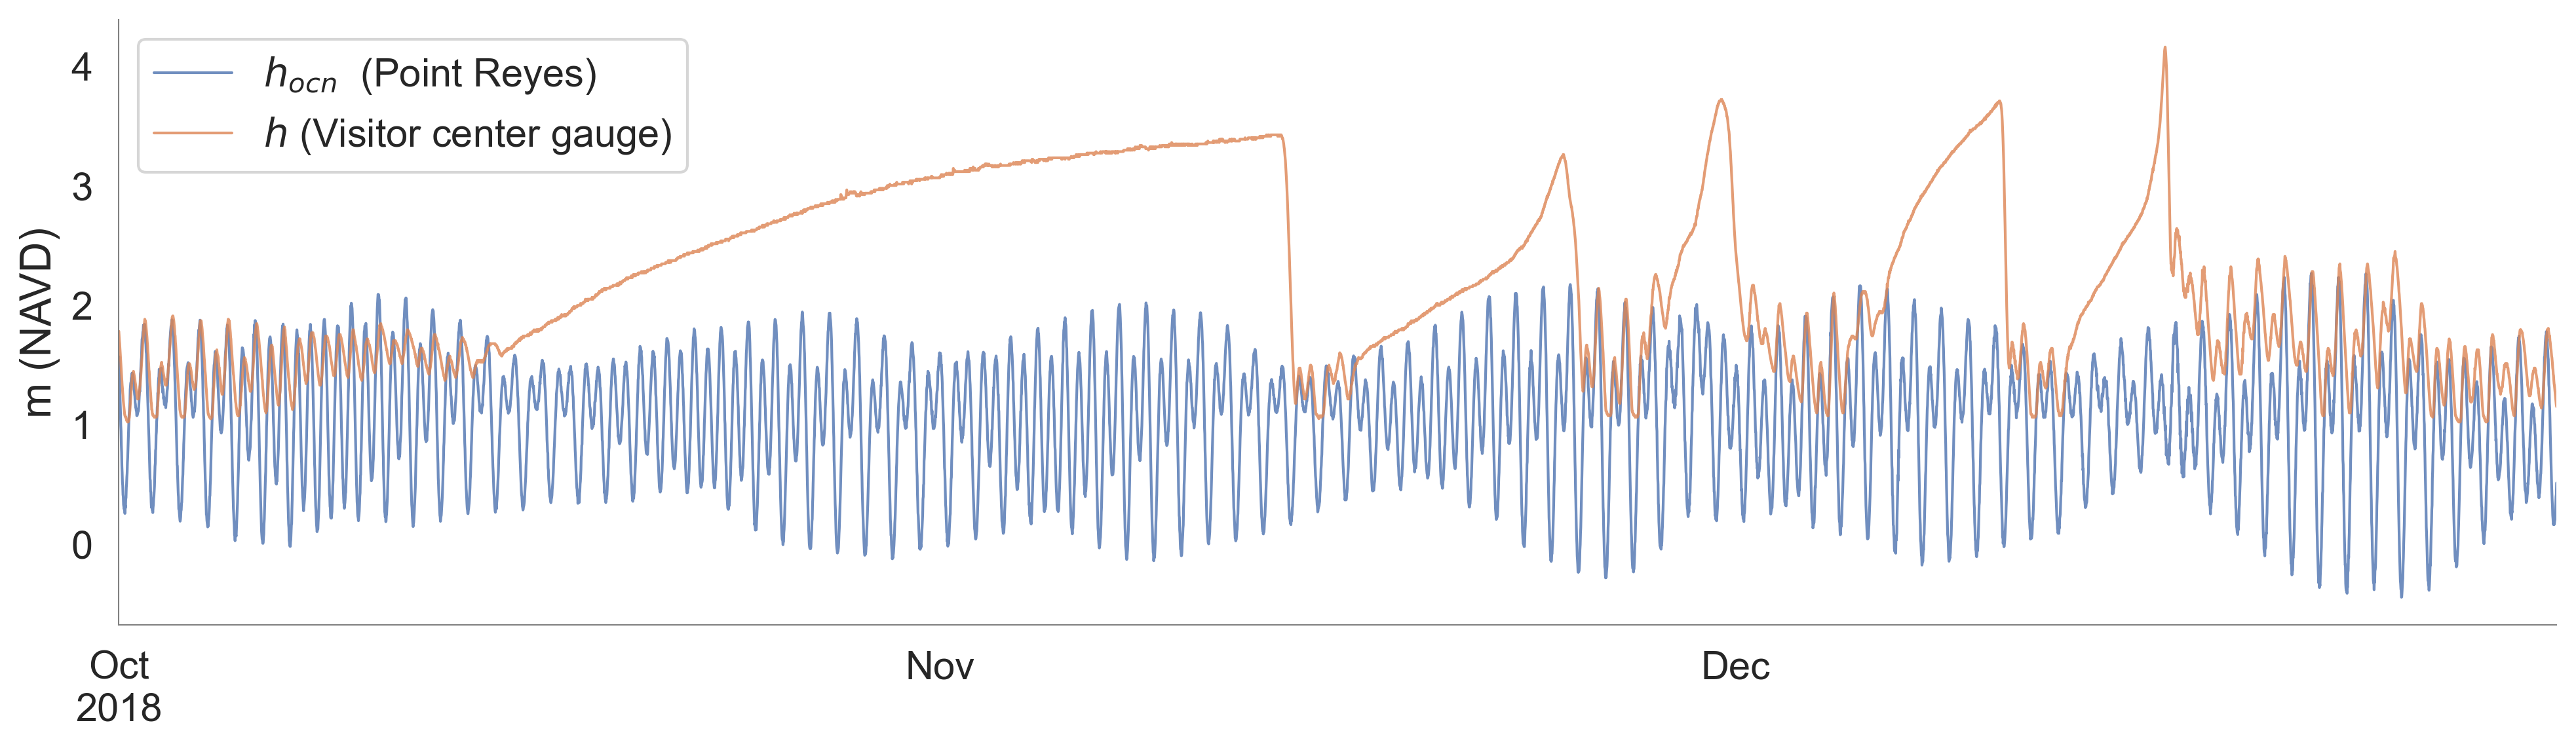

In [30]:
plt.figure(figsize = (16, 4))
year = 2018
inds = (merged.date > pd.to_datetime('{0}-9-30'.format(year)).date()) & \
    (merged.date < pd.to_datetime('{0}-1-1'.format(year + 1)).date())

merged[inds][[  'v', 'visitor_filled']].rename(rename_dict, axis= 1).plot(ax = plt.gca(), alpha = 0.8, lw = 1)
plt.ylabel("m (NAVD)")


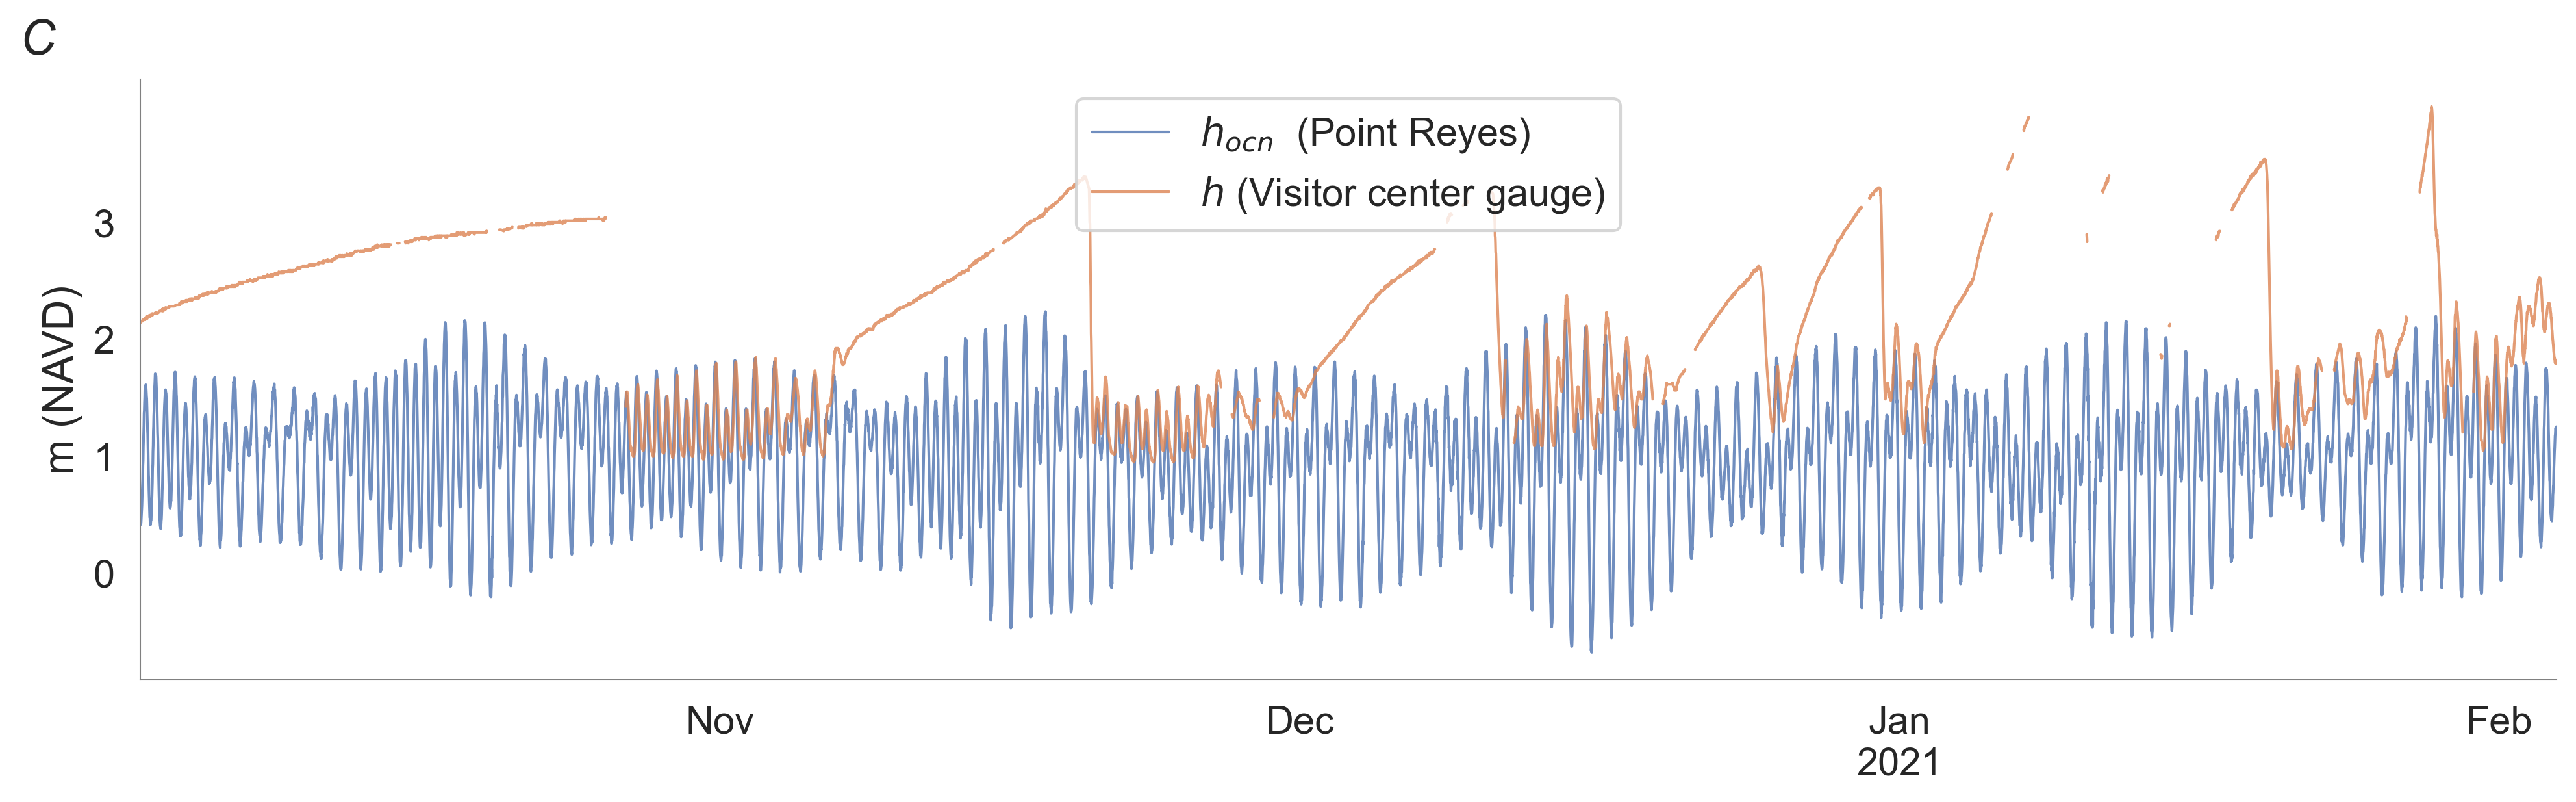

In [31]:
plt.figure(figsize = (16, 4))
year = 2020
inds = (merged.date > pd.to_datetime('{0}-10-1'.format(year)).date()) & \
    (merged.date < pd.to_datetime('{0}-2-4'.format(year+1)).date())

merged[[  'v', 'visitor_filled']].rename(rename_dict, axis= 1
        )[inds].plot(ax = plt.gca(), alpha = 0.8, lw = 1)
plt.ylabel("m (NAVD)")
# plt.title("{0} ".format(year))
plt.yticks([0, 1,2,3]);
ax = plt.gca()
ax.text(-0.05, 1.1, 'C', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

Text(0, 0.5, 'm (NAVD)')

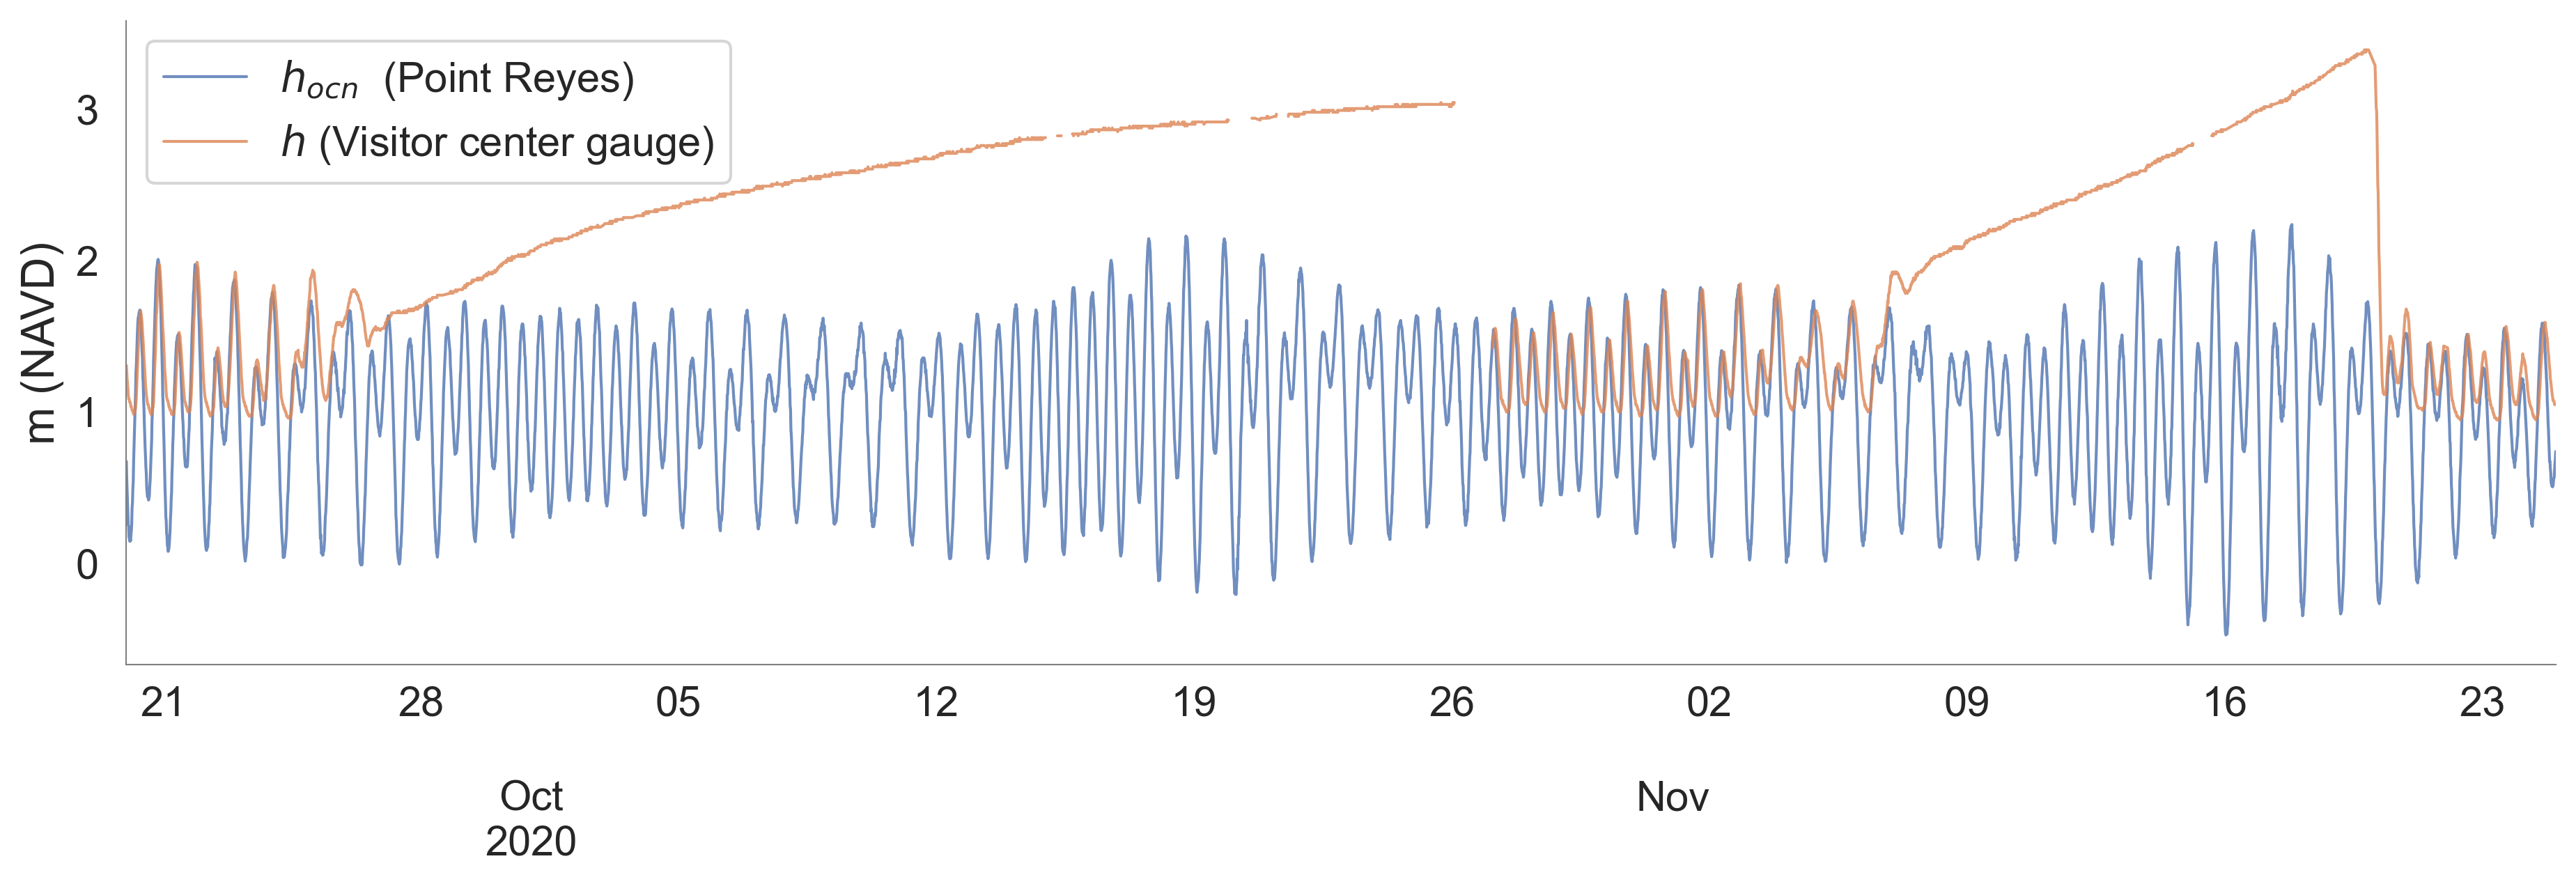

In [32]:
plt.figure(figsize = (15, 4))
year = 2020
inds = (merged.date > pd.to_datetime('{0}-9-19'.format(year)).date()) & \
    (merged.date < pd.to_datetime('{0}-11-25'.format(year)).date())

merged[[  'v', 'visitor_filled']].rename(rename_dict, axis= 1)[inds].plot(ax = plt.gca(), alpha = 0.8, lw = 1)
plt.ylabel("m (NAVD)")
# plt.title("{0} ".format(year))


#### Gauge readings exceeding hypsometric bounds

Check for water levels above 3.63 m NAVD88 (the maximum elevation in the hypsometric survey). These may indicate overbank flooding or gauge error.

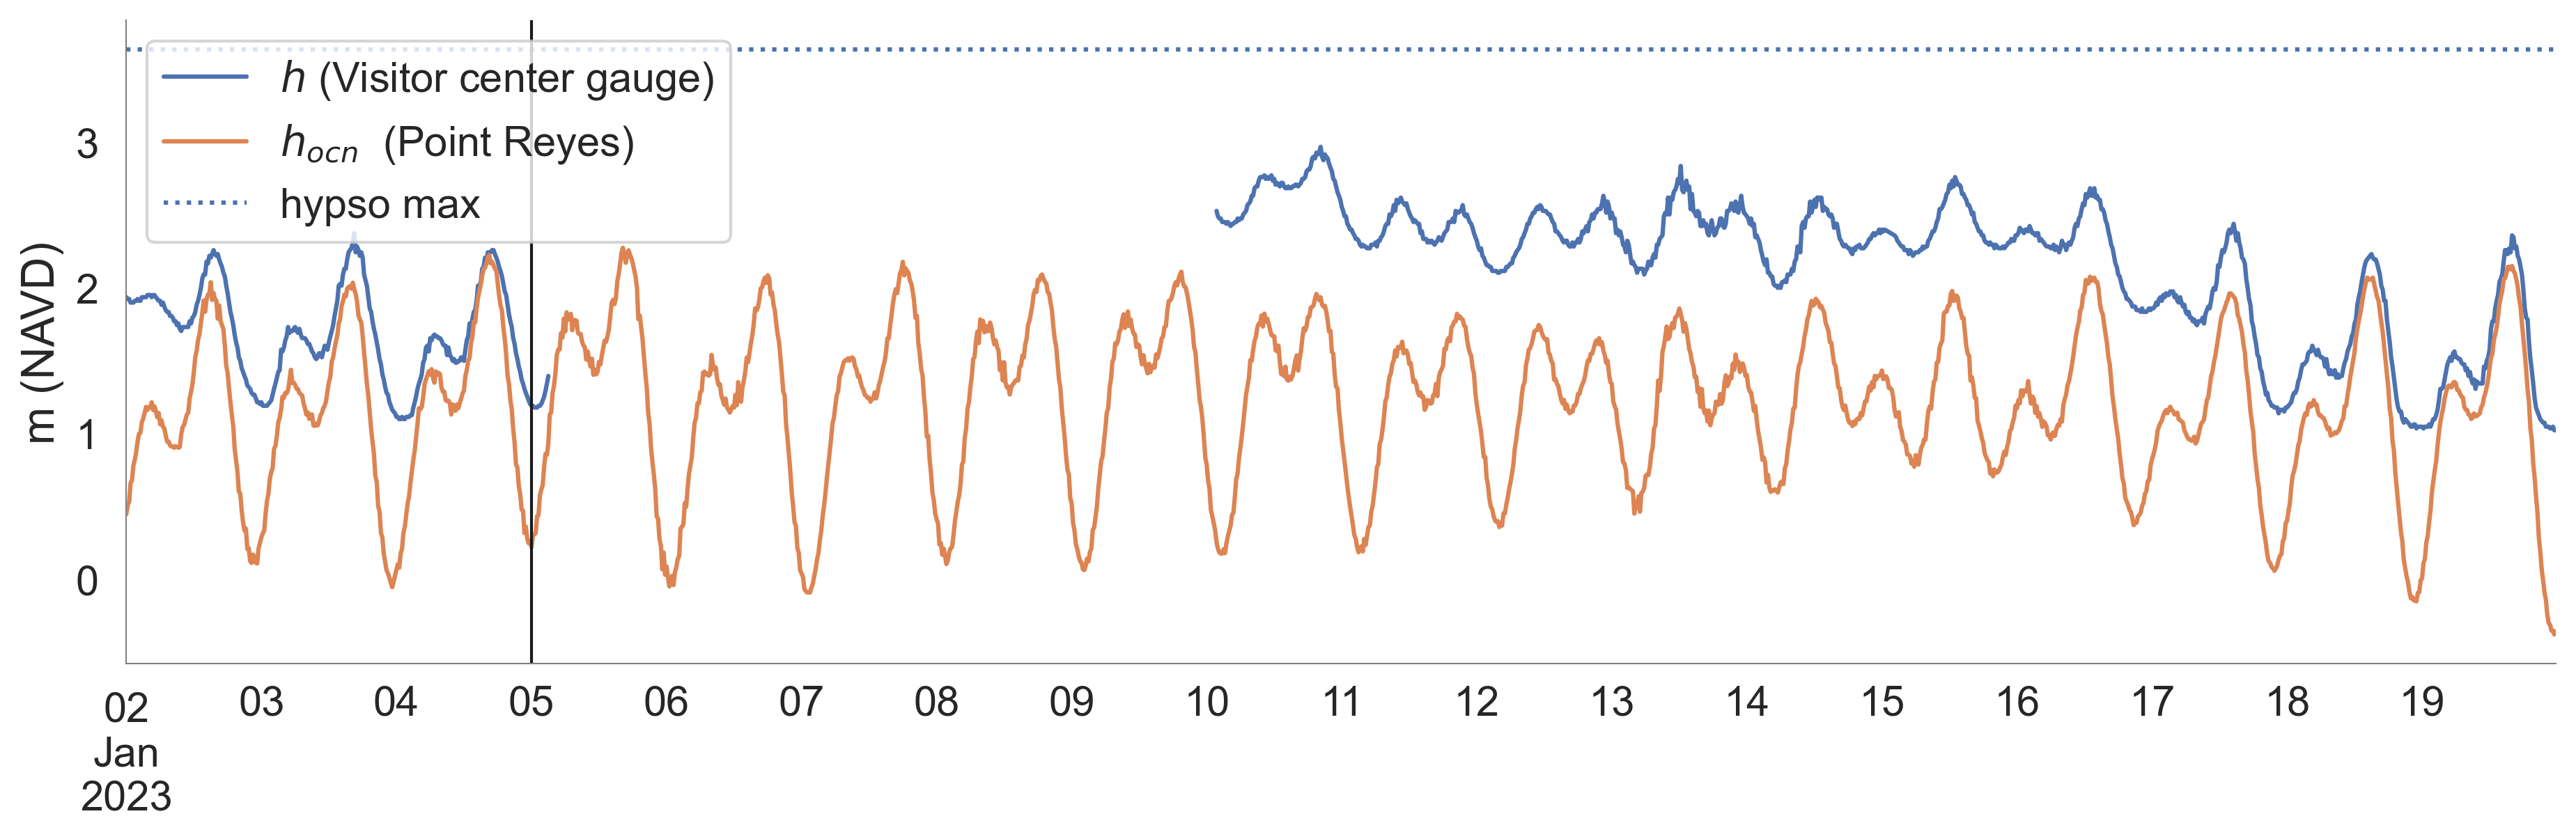

In [33]:
plt.figure(figsize = (15, 4))

inds = (merged.date > pd.to_datetime('2023-1-1').date()) &  (merged.date < pd.to_datetime('2023-1-20').date())

merged[['visitor_filled',  'v']].rename(rename_dict, axis= 1
        )[inds].plot(ax = plt.gca())
plt.ylabel("m (NAVD)")
plt.axhline(3.632104, ls = ':', label = 'hypso max')
plt.axvline(pd.to_datetime('2023-1-5').date(), lw = 1, c = 'k')
plt.legend()


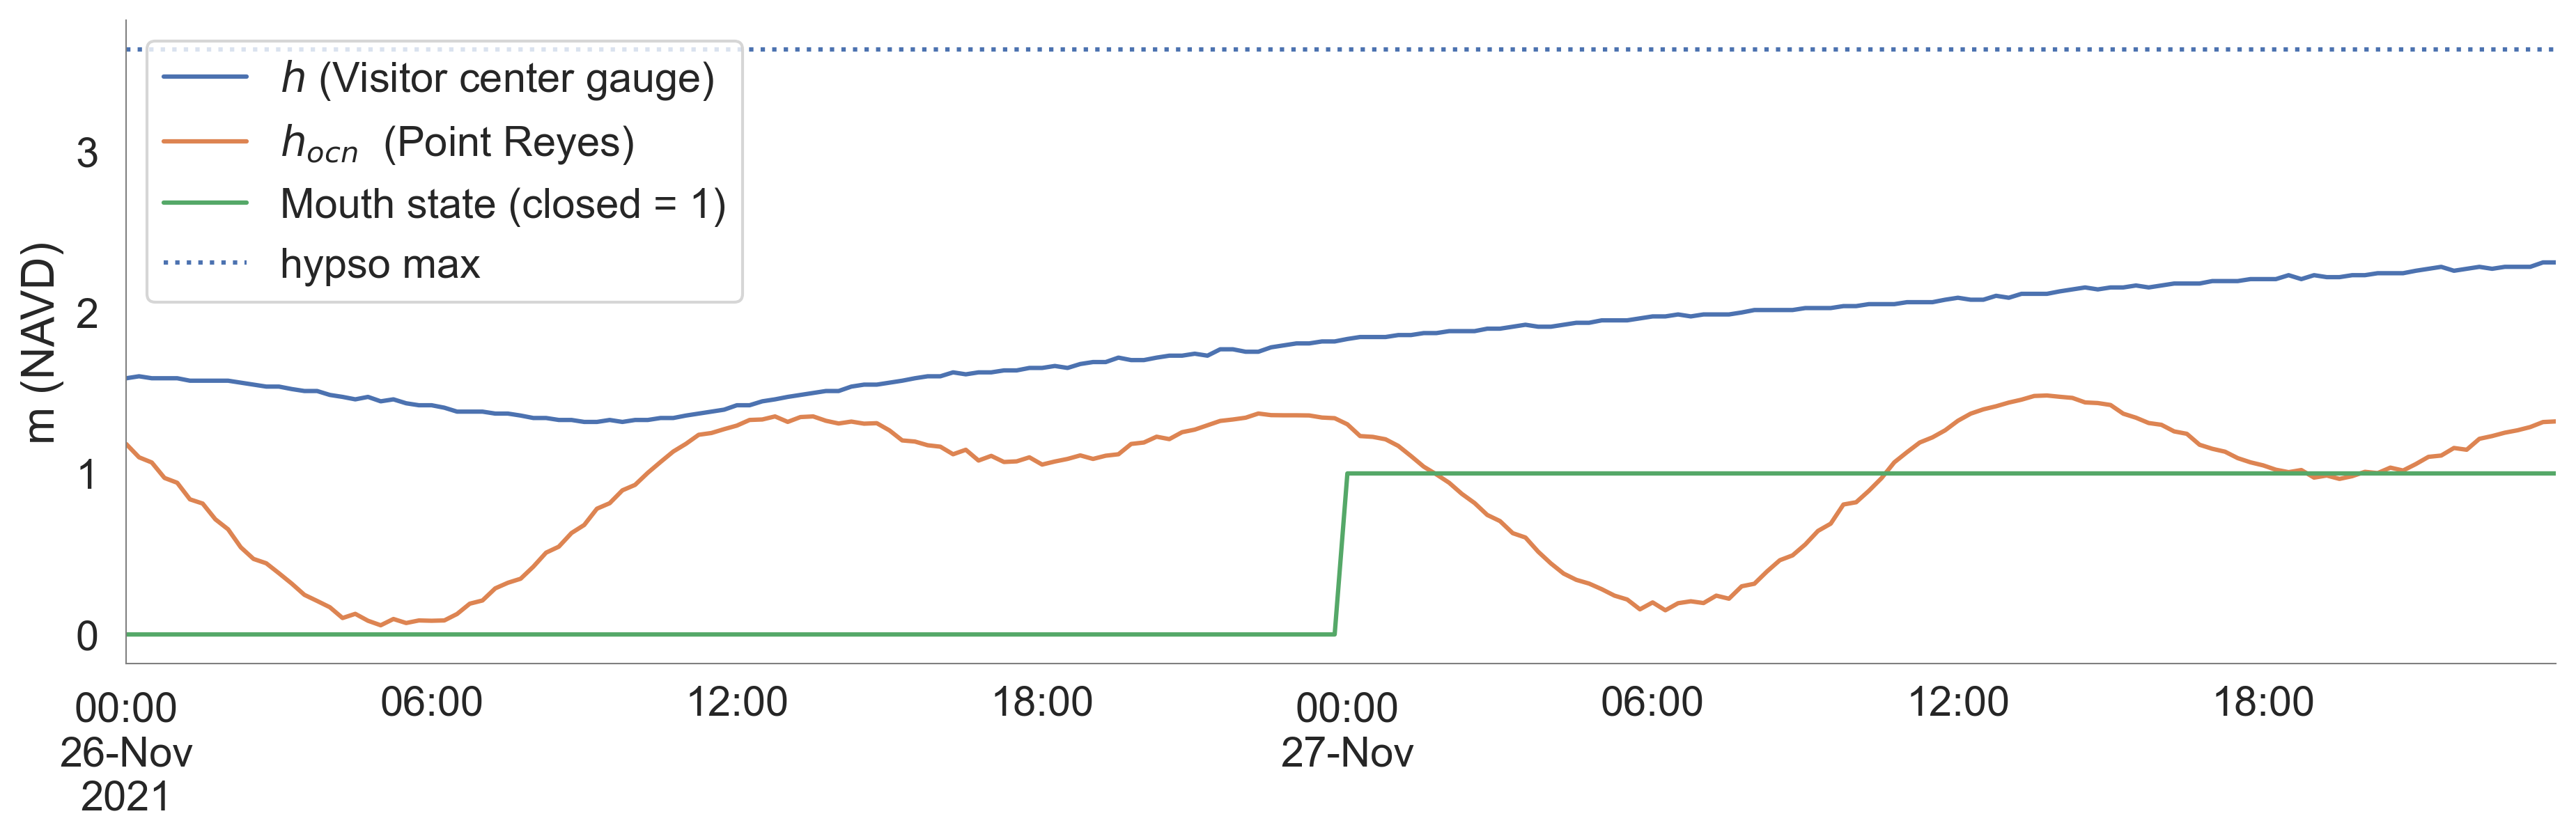

In [34]:
plt.figure(figsize = (15, 4))
inds = (merged.date > pd.to_datetime('2021-11-25').date()) &  (merged.date < pd.to_datetime('2021-11-28').date())

merged[['visitor_filled',  'v', 'State']].rename(rename_dict, axis= 1
        )[inds].plot(ax = plt.gca())
plt.ylabel("m (NAVD)")
plt.axhline(3.632104, ls = ':', label = 'hypso max')
plt.legend()


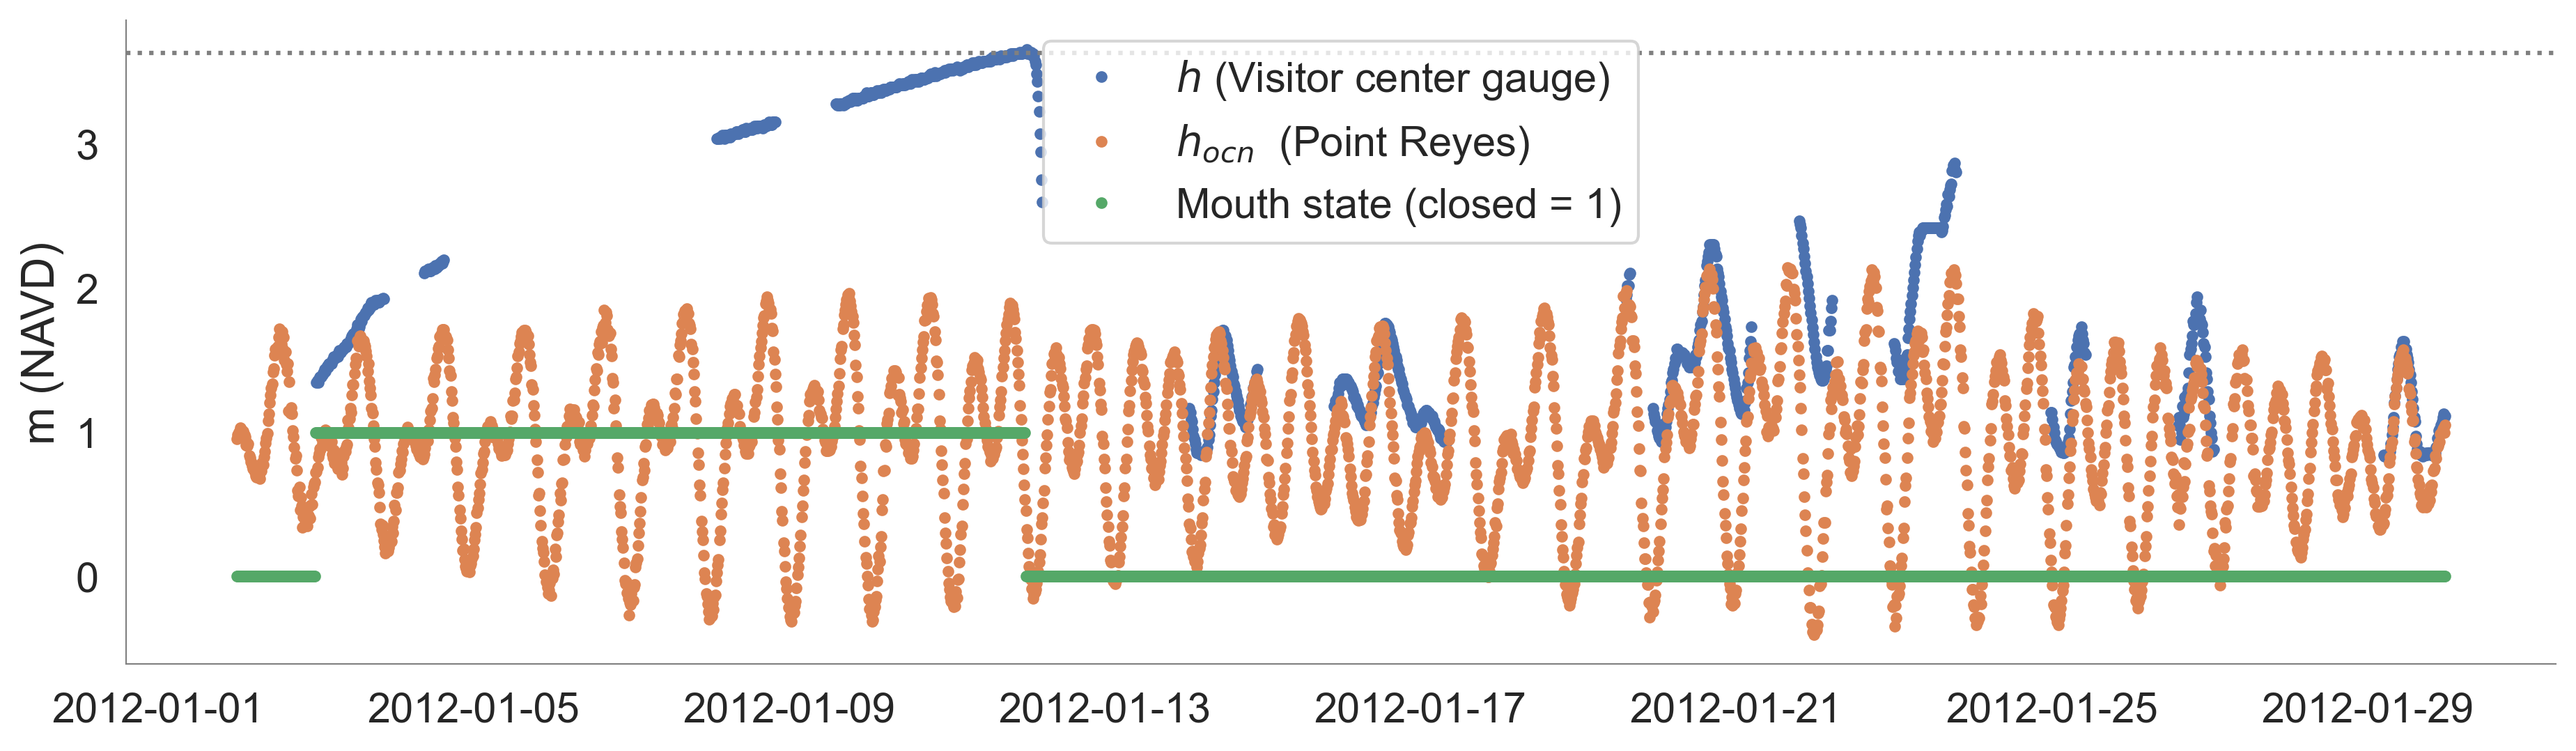

In [35]:
plt.figure(figsize=(15, 4))
inds = (merged.date > pd.to_datetime('2012-1-1').date()) & (merged.date < pd.to_datetime('2012-1-30').date())

# Rename columns for plotting
df_plot = merged[['visitor_filled', 'v', 'State']].rename(
    rename_dict, axis=1
)[inds]

# Plot each column with markers only
for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col], marker='.', linestyle='', label=col)

plt.ylabel("m (NAVD)")
plt.axhline(3.632104, ls=':', color='gray')
plt.legend()